<a href="https://colab.research.google.com/github/BastianRu/Deep-Learning-Foundations-From-Scratch-Journal/blob/main/04-Probabilistic_Neural_Language_Model/ProbabilisticNeuralLModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Just the itos and stoi dictionaries definition

chars = ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

stoi  = { s:i for i, s in enumerate(chars)}
itos = { i:s for s, i in stoi.items()}

###Creating the data-set



In [ ]:
import torch

example_names = ['emma', 'olivia','ava','isabella','sophia','charlotte','mia', 'amelia','harper', 'evelyn']

block_size = 3
xs, ys = [], []

#batching the data according to the block size which is the number of characters we trake to predict the next one
for w in example_names[:5]:
  context = [0] * block_size
  for ch in w + '.':
    xs.append(context)
    ys.append(stoi[ch])
   # print(f'{''.join([itos[ix] for ix in context])} -> {ch}' )
    context = context[1:] + [stoi[ch]]

xs = torch.tensor(xs) #now we got 3 characters as the input for the neural network (which is modificable)
ys = torch.tensor(ys) #labels for the training.

xs.shape, ys.shape

(torch.Size([32, 3]), torch.Size([32]))

###Creating the C lookup table for embed the input

In [ ]:
import torch.nn.functional as F

g=torch.Generator().manual_seed(73)

#We're going to have a single embedding for each vocabulary character
#And for now, it's a 2 dimensional vector
emb_dimensions = 2
C = torch.randn((27, emb_dimensions), generator=g)
#We're going to tune it using backprop later

#We can index into C by using both the one-hot enc + matrix multiplication or just with list indexing
enc = F.one_hot(torch.tensor([1]), num_classes=27).float()

#They will produce the same output
#print(enc @ C)
#print(C[1])

#We're going to use the second method

#Advanced indexing with pytorch

#We not only can index by vectors but by multi-dimensional vectors
embs = C[xs] # three dimensional tensor. C[sx].shape = (N, block_size, dimensions) N = number of examples
#For each example, 3 characters as block size, and for each character, 2 dimensions

#print(C[xs][3, 2])
#print(C[13])

embs

tensor([[[ 0.3408,  0.2297],
         [ 0.3408,  0.2297],
         [ 0.3408,  0.2297]],

        [[ 0.3408,  0.2297],
         [ 0.3408,  0.2297],
         [-1.2031, -0.0674]],

        [[ 0.3408,  0.2297],
         [-1.2031, -0.0674],
         [-0.9134,  0.0893]],

        [[-1.2031, -0.0674],
         [-0.9134,  0.0893],
         [-0.9134,  0.0893]],

        [[-0.9134,  0.0893],
         [-0.9134,  0.0893],
         [ 1.7066,  1.3925]],

        [[ 0.3408,  0.2297],
         [ 0.3408,  0.2297],
         [ 0.3408,  0.2297]],

        [[ 0.3408,  0.2297],
         [ 0.3408,  0.2297],
         [-1.6498,  0.9515]],

        [[ 0.3408,  0.2297],
         [-1.6498,  0.9515],
         [-1.6609, -0.4437]],

        [[-1.6498,  0.9515],
         [-1.6609, -0.4437],
         [ 0.7980, -0.0897]],

        [[-1.6609, -0.4437],
         [ 0.7980, -0.0897],
         [ 2.0920, -1.1984]],

        [[ 0.7980, -0.0897],
         [ 2.0920, -1.1984],
         [ 0.7980, -0.0897]],

        [[ 2.0920, -1

###Creating the hidden layer  

In [ ]:
#The hidden layer recives nin (n outputs) inputs from the first layer, for two dimensional embeddings
#nin will be 6 since block size is 3
#The number of neurons in this layer is a hyperparameter
nin = block_size * emb_dimensions
nout = 100

W1 = torch.randn((nin, nout), generator=g)
b1 = torch.randn(nout, generator=g) #100 biases for 100 neurons
W1.shape

torch.Size([6, 100])

###Forward pass

In [ ]:

#We'd like to compute W*X + b.
#Which is a very compact and efficient way to apply each example (which is a tensor of 6 elements, after squeezing out extra dimensions) for each neuron in the hidden layer
#producing nout outputs (100 for this case) that will later be converted into 27 logits.

#But we can't directly multiply distinct dimension matrices. W1.shape = (6, 100), embs.shape = (N, 3, 2)
#therefore we have to squeeze out the third dimension in embs, so that for each example we have a single tensor with 6 values

#We want the first dimension (rows) to be the number of examples (such as before), and the second, a single tensor of values
#An interesting fact here is that we're already giving to the network a certain positional encoding (which is important for language models)
#since the embedding for the secuence 'abc' would be [C[1], C[2], C[3]] and the embedding for 'cba' would be [C[3], C[2], C[1]]
embs = embs.view((embs.shape[0], 6)) #The faster way to do that is by using torch.view() function

#Now we can feed forward
pre_act = embs @ W1 + b1 #W*X + b
act = pre_act.tanh() #non-linearity

act.shape


torch.Size([32, 100])

###Output layer

In [ ]:
#Now last layer is fed with the outputs from the previous layer (which is 100) and produces 27 outputs (since we're working with single next character prediction)
W2 = torch.randn((nout, 27), generator=g)
b2 = torch.randn(27, generator=g)

#forward pass
logits = act @ W2 + b2 #(N, 100) @ (100, 27) + (,100) = (N, 27)
counts = logits.exp() #softmax
probs = counts / counts.sum(dim=1, keepdim=True)

###Negative log likelihood loss

In [ ]:
#We apply the negative log likelihood as before

#for each example, access to its label index (next real letter), get its log and sum it
loss = -probs[torch.arange(len(xs)), ys].log().mean()
loss

tensor(19.7952)

In [ ]:
logits.shape, ys.shape


(torch.Size([32, 27]), torch.Size([32]))

###The Cross-Entropy function and Softmax funcion in PyTorch

In [ ]:
#We've been computing the NLL and Softmax functions manually.
#But in fact, this is inefficient for many reasons.
#PyTorch have this functions implemented.

#Cross-Entropy function is conceptually: Softmax + Negative Log LikeliHood
#It recives the logits and targets and returns the total loss


loss = F.cross_entropy(logits, ys)

#In addition, there's also a funcion which automatically computes softmax called the same
probs = F.softmax(logits, dim=1) #We still to specify the dimension


In [ ]:
#Just a quickly re-start

#Let's put all the parameters in one single list
parameters = [C, W1, W2, b1, b2]

for p in parameters:
  p.data = torch.randn(p.shape, generator=g)
  p.grad = None

###Training cycle

In [ ]:

#All params require gradient
for p in parameters:
  p.requires_grad = True

batch_size = 32

for _ in range(1):

    #batching
    indices = torch.randint(0, xs.shape[0], (batch_size,))

    #forward pass
    #Note: Now with the batching we're indexing only through the random generated indices
    embs = C[xs[indices]].view((embs[indices].shape[0], 6)) #Embedding the examples
    acts = (embs @ W1 + b1).tanh() # hidden layer pass

    logits = acts @ W2 + b2
    #probs = F.softmax(logits) #output layer (just used at inference)

    #loss
    loss = F.cross_entropy(logits, ys[indices])
    print(loss.item())

    #backward pass
    for p in parameters: #zero-gradient
      p.grad = None
    loss.backward() #backprop

    for p in parameters:
      p.data += -0.1*p.grad


16.444303512573242


###Some limits...

In [ ]:
#We're not actually able to converge to a 0.0 loss in this model since there are many examples
#in our training set like '... -> a', '... -> o', '... -> b' and so on, which tell the model that the exact same input can produce
# different outputs. This inherent ambiguity prevents the network from perfectly
# fitting all examples (commonlly called overfitting)

logits.max(1)

torch.return_types.max(
values=tensor([13.6753, 16.0367, 16.0367, 12.3232, 15.0924, 20.4331, 14.5771, 16.6372,
        15.4886, 16.0367, 20.4331, 19.8508, 15.6736, 15.2493, 16.0367, 20.4331,
        18.8609, 20.4331, 12.3232, 13.1026, 18.8609, 16.0367, 14.2057, 15.0924,
        16.0367, 19.8508, 13.3749, 16.2808, 16.0367, 15.2493, 15.6736, 16.2808],
       grad_fn=<MaxBackward0>),
indices=tensor([ 4, 26, 26,  2, 19,  9, 17, 26,  2, 26,  9,  2,  3, 26, 26,  9, 26,  9,
         2,  7, 26, 26,  2, 19, 26,  2,  4,  4, 26, 26,  3,  4]))

In [ ]:
ys

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

###Mini-batching

In [ ]:
#Since we're working with a larger data set, we have to some way otptimize the
#training process.

#the bigger the batch, the less efective the optimization but the gradient is more accurate
#the smaller the batch, the more efective the optimization but the gradient is unaccurate
batch_size = 32
torch.randint(0, xs.shape[0], (batch_size,)) #32 random indices from the training set

#We're going to use this line in our training cycle

tensor([15, 25, 10, 12, 25, 14,  5, 31,  9,  5, 16, 25, 10,  0, 20, 20,  3,  1,
        25,  4, 28, 16,  6, 30, 17, 21, 28, 23, 30, 17, 12,  2])

###The Traing, Dev and Test Splits

We split the dataset into **training, dev (validation) and test sets** because training a model and *evaluating* a model are two fundamentally different goals.



#### Training set

The *training set* is the only data the model is allowed to learn from.

Here, the objective is to minimize the loss so the model can:
- capture statistical regularities,
- learn useful representations,
- and fit the data *well enough* without simply memorizing it.

However, a very low training loss alone does *not* guarantee good generalization.  
A model with too much capacity can always adapt itself to the quirks and noise of the training data.


#### Dev (validation) set

The *dev set* is used to simulate *unseen but plausible future data*.

It is not used to update weights.  
Instead, it is used to:
- detect overfitting,
- compare model capacities,
- tune hyperparameters (learning rate, model size, regularization, etc.).

Why can dev loss be higher than training loss?

Because overfitting happens when the model learns patterns that are:
- specific to the training distribution,
- not representative of the underlying data-generating process.

In that case, the model performs well on training examples but fails to generalize.

A good model configuration is one where both training and dev losses are low and close to each other.



#### Test set

The test set* is used only once, at the very end.

Its purpose is to provide an unbiased estimate of how well the model generalizes after *all decisions have been made*.

Importantly:
- If we use the test set to tune hyperparameters,
- or to decide between models,

then it stops being a test set and becomes part of the training process.

This would lead to overly optimistic results and poor real-world performance.

In [ ]:
#Note: You need to run this line of code once
#load all the data-set
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt -O names.txt #source

--2026-07-05 19:16:40--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.03s   

2026-07-05 19:16:40 (8.54 MB/s) - ‘names.txt’ saved [228145/228145]



In [ ]:
#We need to divide our traning set in three splits
#Commonlly called, Training Split (80%), Dev/Validation Split (10%) and Test Split (10%)

import random

with open('names.txt', 'r') as f:
    names = f.read().splitlines()

#Build the data-set as before
block_size = 3
xs, ys = [], []

for w in names[:10000]:
  context = [0] * block_size
  for ch in w + '.':
    xs.append(context)
    ys.append(stoi[ch])
   # print(f'{''.join([itos[ix] for ix in context])} -> {ch}' )
    context = context[1:] + [stoi[ch]]


random.seed(42) #Deterministic seed for reproducibility
random.shuffle(names) #Shuffle all the data-set (this allows us to get a non-biased data)

#Let's create the training, dev and test split (the following 3 lines are unnecessary, just for you to visualizate the distributions)
Xtrain, Ytrain = [], [] #80%
Xdev, Ydev = [], [] #10%
Xtest, Ytest = [], [] #10%

# Calculate split indices properly
train_split_idx = int(len(xs) * 0.8)
dev_split_idx = int(len(xs) * 0.9)

# Assign data to splits, ensuring X and Y are aligned and splits are distinct
Xtrain, Ytrain = torch.tensor(xs[:train_split_idx]), torch.tensor(ys[:train_split_idx])
Xdev, Ydev = torch.tensor(xs[train_split_idx:dev_split_idx]), torch.tensor(ys[train_split_idx:dev_split_idx])
Xtest, Ytest = torch.tensor(xs[dev_split_idx:]), torch.tensor(ys[dev_split_idx:])

Xdev.shape, Ydev.shape

(torch.Size([7140, 3]), torch.Size([7140]))

In [ ]:
#Initialize the network (here you can tune the parameters as you want (look the previous code cell to tune the block size))
g=torch.Generator().manual_seed(73)

emb_dimensions = 2 #embedding number of dimensions
C = torch.randn((27, emb_dimensions), generator=g)

nin = block_size * emb_dimensions #this is the fan-in to the first hidden layer
nout = 100 #Number of neurons for the hidden layer

W1 = torch.randn((nin, nout), generator=g) * (5/3) / ((block_size * emb_dimensions)**0.5)
b1 = torch.randn(nout, generator=g) * 0

W2 = torch.randn((nout, 27), generator=g) * 0.01 #It's dangerous to set the weights to absolute 0, it can end with a whole set of death neurons
b2 = torch.randn(27, generator=g) * 0 #so the initial loss becomes closer to the minimun loss (calculated by -ln(1/27)) [LOOK AT KAMING HE SECTION]

parameters = [C, W1, W2, b1, b2]

for p in parameters:
  p.requires_grad = True

batch_size = 32 #batch size for training

Getting the optimal learning rate

In [ ]:
import torch

lr_exp = torch.linspace(-3, 0, 1000) #this will give us the exponents for the actual leraning rate, it relies on the range found by hand
lr = 10**lr_exp

In [ ]:
#We create some tracking lists to plot later
lr_used = []
lossi = []

#Training

def train_model(batch_size, steps, lr):
  for _ in range(steps):

    #batching
    indices = torch.randint(0, Xtrain.shape[0], (batch_size,))

    #forward pass
    #Note: Now with the batching we're indexing only through the random generated indices
    embs = C[Xtrain[indices]].view((-1, 6)) #Embedding the examples
    acts = (embs @ W1 + b1).tanh() # hidden layer pass

    logits = acts @ W2 + b2
    #probs = F.softmax(logits) #output layer (just used at inference)

    #loss
    loss = F.cross_entropy(logits, Ytrain[indices])
    print(loss.item())

    #backward pass
    for p in parameters: #zero-gradient
      p.grad = None
    loss.backward() #backprop

    for p in parameters:
      p.data += -lr*p.grad

train_model(batch_size, steps=1, lr=0.1)

3.3118464946746826


In [ ]:
#We're going to use the dev set to evaluate how accurate the model does
#This flag tells to torch that we won't use the gradients flow
with torch.no_grad():
#One forward pass to all the dev trai examples
  embs = C[Xdev].view(-1, 6) #THIS 6 IS HARD CODED / REMEMBER ME LATER, THIS SHOULD BE BLOCK_SIZE * EMB_DIMS
  act = (embs @ W1 + b1).tanh()
  logits = act @ W2 + b2
  loss = F.cross_entropy(logits, Ydev)
  print(loss.item())


3.215862512588501


###Kaming He Inicialization


In [ ]:
#Due to the activation funcionts being satuared o barely used when feed fowarding the MLP
#it becomes necessary to introduce the normalization concept

#the pre-activations at the initialization are following a gaussian distribution but expanded when its standard deviation
#is greater than the regular gaussian one which is 1.

#Multiply a dataset by a certain number is called scaling in statistics. If we compute the dataset standard deviation, let's call it
#'s1', and then we multiply the dataset elementwise by a certain number, let's call it 'a'. The new standard deviation will be 's2 = a*s1'

#The paper https://arxiv.org/pdf/1502.01852 "Kaming He" poses an interesting insight to fight this problem.
#We want to preserve as long as posible the pre-activations standard deviation roughly 1. So it comes the question...which number do i multiply the dataset by so
#the new standard deviation is 1. In other words we're trying to guess 'a'. ################################################FIX##################################

#it turns out to be that number can be calculated using the following formula
# std = gain / √fan-in
#Where fan-in is the number of feature that the layer has. And gain is a constant which relies on activation function

#The gain for tanh function is 5/3

#All the changes were applied in the net initialization block cell
#With all fo this fixes we achieve a very smaller loss, closer to its minimun initiaization value which is -ln(1/27) = 3.29


### Batch Normalization


In [ ]:
#We want the pre-activacions of the hidden layer to be roughly gaussian so the tanh does not get too saturated.
#With Batch Normalization we normalize those pre-activations, we get an actual normal distribution again after the pass w*x + b
#The oficial paper(https://arxiv.org/pdf/1502.03167) which introduced BN, poses the following opperation to achieve that.

#1. Calculate the mean over all the examples in the batch
#For each example we got 100 outputs, we want to normalize
#each output. To do that, the mean over all the mini-batch examples is required
#Then is dim 0, not 1.

#One single forward pass
embs = C[Xtrain].view(-1, 6)
preacts = embs @ W1 + b1

means = preacts.mean(dim = 0, keepdim=True) #dim = 1 so the rows are squeezed out

#2. Calculate the variance
std = preacts.std(dim = 0, keepdim=True) #In the paper they use the square root of variance + epsilon
#where epsilon is a very tiny number that prevents the by 0 division

#3. Normalize
norm_xi = (preacts - means) / std

norm_xi.shape

torch.Size([57117, 100])

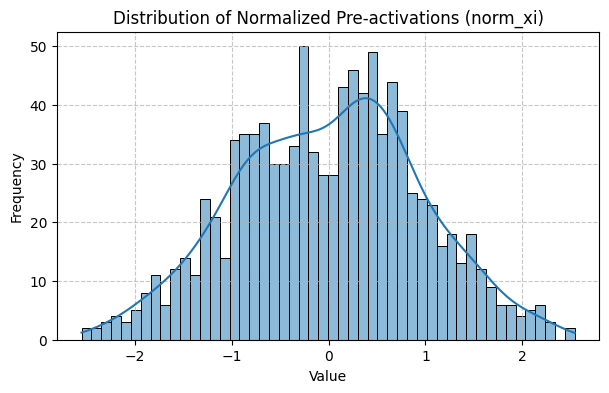

Mean of norm_xi: 0.0000
Standard deviation of norm_xi: 0.9492


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.histplot(norm_xi.view(-1).detach().numpy(), bins=50, kde=True)
plt.title('Distribution of Normalized Pre-activations (norm_xi)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f'Mean of norm_xi: {norm_xi.mean():.4f}')
print(f'Standard deviation of norm_xi: {norm_xi.std():.4f}')

###Batch Norm Gain and Batch Norm Bias

In [ ]:
#In statistics they're called scaling component and shifting component
#allow us to give it back its freedom of deciding the best weight and bias configuration
#to minimize the loss possible loss since the batch normalization layer itself is too restrictive
#We don't want the pre-acts to be always forced to be normal.

#By the way, due to simple mathematical reasons, the BN operation cancels out
# the original layer bias (b1), making it redundant. Instead of that, we'll use the new BN bias as the layer bias

bngain = torch.ones((1, nout)) #Initialize with ones so the first forward pass will just be 1 * norm_x
bnbias = torch.zeros((1, nout)) #Initialize with ones so the first forward pass will just be norm_x + 0 (avoiding the "hockey stick" issue during train)

#The fourth and last step is now:

preacts = bngain * norm_xi + bnbias

preacts.shape


torch.Size([57117, 100])

In [ ]:
parameters = [C, W1, W2, b1, b2, bngain, bnbias]
#Notice that now we're computing the the mean and standard deviation over all the examples in the mini-batch
#So activations are not just a function of the input + weights and bias, but of all the other examples in the batch

# Ensure all parameters require gradients since we just added bngain and bnbias to our parameters list
for p in parameters:
  p.requires_grad = True

#Training
for _ in range(1000):

  #batching
  indices = torch.randint(0, Xtrain.shape[0], (batch_size,))

  #forward pass
  embs = C[Xtrain[indices]].view((-1, 6)) #Embedding the examples
  pre_acts = (embs @ W1 + b1) # hidden layer pass

  #batch normalization
  pre_acts = (pre_acts - pre_acts.mean(dim = 0, keepdim=True)) / pre_acts.std(dim = 0, keepdim=True)
  pre_acts = bngain * pre_acts + bnbias #we add the batch scaling and shifting
  acts = pre_acts.tanh()
  logits = acts @ W2 + b2

  #loss
  loss = F.cross_entropy(logits, Ytrain[indices])

  #backward pass
  for p in parameters: #zero-gradient
    p.grad = None
  loss.backward() #backprop

  for p in parameters:
    p.data += -0.01*p.grad

print(loss.item())

2.7637360095977783


In [ ]:
#Calibrate the batch norm at the end to ensure inference

with torch.no_grad():
  #we pass the entire training set
  raw_embs = C[Xtrain]
  embs = raw_embs.view(raw_embs.shape[0], emb_dimensions * block_size)
  pre_acts = embs @ W1 + b1
  #Here we measure the mean and standart deviaton over the entire training set
  bnmean = pre_acts.mean(0, keepdim=True)
  bnstd = pre_acts.std(0, keepdim=True)

In [ ]:
@torch.no_grad() #This decorator disables gradient tracking, it's not necessary since we're not going to backpropagate here
def split_loss(split):
  x, y = {
      'train': (Xtrain, Ytrain),
      'dev': (Xdev, Ydev),
      'test': (Xtest, Ytest)
  }[split]
  raw_embs = C[x]
  #Forward (hidden)
  embs = raw_embs.view(raw_embs.shape[0], emb_dimensions * block_size)
  pre_acts = embs @ W1 + b1
  pre_acts = (pre_acts - bnmean) / bnstd
  pre_acts = bngain * pre_acts + bnbias
  acts = pre_acts.tanh()

  #Forward (ouput)
  logits = acts @ W2 + b2 #(N, vocabulary size)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('dev')

train 2.7685883045196533
dev 2.7780377864837646
